In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# =========================================================
# 0. 读入数据 & 定义 A, Y, X
# =========================================================
# csv_path = "rhc.csv"      # 改成你自己的路径

url = "https://hbiostat.org/data/repo/rhc.csv"  # 官方公开地址

# /Users/zhangzhiheng/Downloads/rhc.csv
# url = "/Users/zhangzhiheng/Downloads/rhc.csv"

df = pd.read_csv(url)


# df = pd.read_csv(csv_path)

# --- Treatment A: swang1 是否 RHC ---
A = (
    df["swang1"]
    .astype(str).str.strip().str.upper()
    .eq("RHC")
).astype(int).values  # shape (n,)

# --- Outcome Y: dth30 是否 YES（死亡）---
# 如果你想改成“生存=1”，把 == "YES" 换成 == "NO" 即可
Y = (
    df["dth30"]
    .astype(str).str.strip().str.upper()
    .eq("YES")
).astype(int).values  # shape (n,)

# 协变量 X：除去 swang1, dth30 之外的所有列
X_raw = df.drop(columns=["swang1", "dth30"])

# =========================================================
# 1. 预处理：数值 / 分类拆分，one-hot，缺失填补，标准化
# =========================================================
# 数值列 & 非数值（视作类别）列
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_raw.columns if c not in num_cols]

# 对类别变量做 one-hot，drop_first 避免完全共线
X_dum = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

# 替换 inf + 缺失值，用均值填补
X_dum = X_dum.replace([np.inf, -np.inf], np.nan)
X_dum = X_dum.fillna(X_dum.mean())

# 标准化（零均值单位方差）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dum.values.astype(float))

X_cols = list(X_dum.columns)   # one-hot 后每一维的名字
n, p = X_scaled.shape
print(f"Data after preprocessing: n={n}, p={p} (dummy-coded features)")

# =========================================================
# 2. 建立“原始变量 -> dummy 特征”的映射，用于聚合重要性
# =========================================================
feature_groups = {}

# 数值特征：自己就是一组
for col in num_cols:
    if col in X_cols:
        feature_groups[col] = [col]

# 类别特征：所有前缀为 "col_" 的 dummy 归到一个组
for c in cat_cols:
    prefix = c + "_"
    feats = [col for col in X_cols if col.startswith(prefix)]
    if feats:
        feature_groups[c] = feats

print(f"Number of original X variables: {len(feature_groups)}")

# 一个小工具：给定系数向量 coef (对 X_scaled 的每一维)，
# 把 |coef| 按原始变量聚合并排序
def aggregate_importance(coef_vector):
    importance = {}
    for var, feats in feature_groups.items():
        idxs = [X_cols.index(f) for f in feats if f in X_cols]
        if not idxs:
            continue
        importance[var] = float(np.sum(np.abs(coef_vector[idxs])))
    # 从大到小排序
    return sorted(importance.items(), key=lambda kv: kv[1], reverse=True)

# =========================================================
# 3. 排序 2.1：哪个 X 维度对预测 A 最重要？
#    使用 L1-Logistic 回归 A ~ X
# =========================================================
logit_A = LogisticRegression(
    penalty="l1",
    solver="liblinear",   # 支持 L1
    max_iter=1000
)
logit_A.fit(X_scaled, A)
coef_A = logit_A.coef_[0]   # 对 X_scaled 每一列的系数

rank_for_A = aggregate_importance(coef_A)

print("\n=== 2.1 预测 A 最重要的前 20 个原始协变量 (X_j) ===")
for name, score in rank_for_A[:20]:
    print(f"{name:15s}  importance = {score:.4f}")

# =========================================================
# 4. 排序 2.2：在预测 Y | (X, A) 时，哪个 X 维度最重要？
#    使用 L1-Logistic 回归 Y ~ [X, A]
#    —— 我们只对 X 部分的系数做聚合，A 自己单独一维
# =========================================================
# 设计矩阵：前 p 列是标准化后的 X，最后一列是未标准化的 A
XA = np.column_stack([X_scaled, A.reshape(-1, 1)])

logit_Y = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)
logit_Y.fit(XA, Y)

coef_Y = logit_Y.coef_[0]   # 长度 p+1
coef_Y_X = coef_Y[:-1]      # 前 p 维对应 X
coef_Y_A = coef_Y[-1]       # 最后一维对应 A 本身

rank_for_Y = aggregate_importance(coef_Y_X)

print("\n=== 2.2 在预测 Y | (X, A) 时，对 Y 最重要的前 20 个原始协变量 (X_j) ===")
for name, score in rank_for_Y[:20]:
    print(f"{name:15s}  importance = {score:.4f}")

print(f"\n系数中，treatment A 的绝对系数 |beta_A| = {abs(coef_Y_A):.4f}")


Data after preprocessing: n=5735, p=80 (dummy-coded features)
Number of original X variables: 61

=== 2.1 预测 A 最重要的前 20 个原始协变量 (X_j) ===
sadmdte          importance = 1.6232
dschdte          importance = 1.5831
cat1             importance = 1.2757
ninsclas         importance = 0.5937
cat2             importance = 0.5736
pafi1            importance = 0.5093
surv2md1         importance = 0.4246
paco21           importance = 0.3412
resp1            importance = 0.2914
card             importance = 0.2527
dnr1             importance = 0.2316
meanbp1          importance = 0.2242
hrt1             importance = 0.2138
ca               importance = 0.2001
wtkilo1          importance = 0.1941
ph1              importance = 0.1850
pot1             importance = 0.1807
transhx          importance = 0.1622
t3d30            importance = 0.1621
neuro            importance = 0.1609

=== 2.2 在预测 Y | (X, A) 时，对 Y 最重要的前 20 个原始协变量 (X_j) ===
t3d30            importance = 24.0768
sadmdte          importance =

=== 2.1 预测 A 最重要的前 20 个原始变量 (按 |corr(X_j, A)| 排序) ===
aps1        importance = 0.2386
meanbp1     importance = 0.2128
pafi1       importance = 0.2036
cat2        importance = 0.1862
neuro       importance = 0.1607
card        importance = 0.1433
crea1       importance = 0.1300
resp        importance = 0.1285
hema1       importance = 0.1272
cat1        importance = 0.1267
wtkilo1     importance = 0.1223
paco21      importance = 0.1164
seps        importance = 0.1154
alb1        importance = 0.1153
dnr1        importance = 0.1063
surv2md1    importance = 0.0963
chrpulhx    importance = 0.0913
transhx     importance = 0.0842
resp1       importance = 0.0803
ninsclas    importance = 0.0782

=== 2.2 在 (X_j, A) → Y 中最重要的前 20 个原始变量 (按 partial corr 排序) ===
t3d30       importance = 0.8959
death       importance = 0.5196
surv2md1    importance = 0.3857
dthdte      importance = 0.2519
scoma1      importance = 0.2325
dnr1        importance = 0.2172
lstctdte    importance = 0.2160
aps1        import

/var/folders/6m/31x0jbln169_6g4fn60b2dsc0000gn/T/ipykernel_46430/1573543048.py:111: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6m/31x0jbln169_6g4fn60b2dsc0000gn/T/ipykernel_46430/1573543048.py:111: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6m/31x0jbln169_6g4fn60b2dsc0000gn/T/ipykernel_46430/1573543048.py:111: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6m/31x0jbln169_6g4fn60b2dsc0000gn/T/ipykernel_46430/1573543048.py:111: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/o

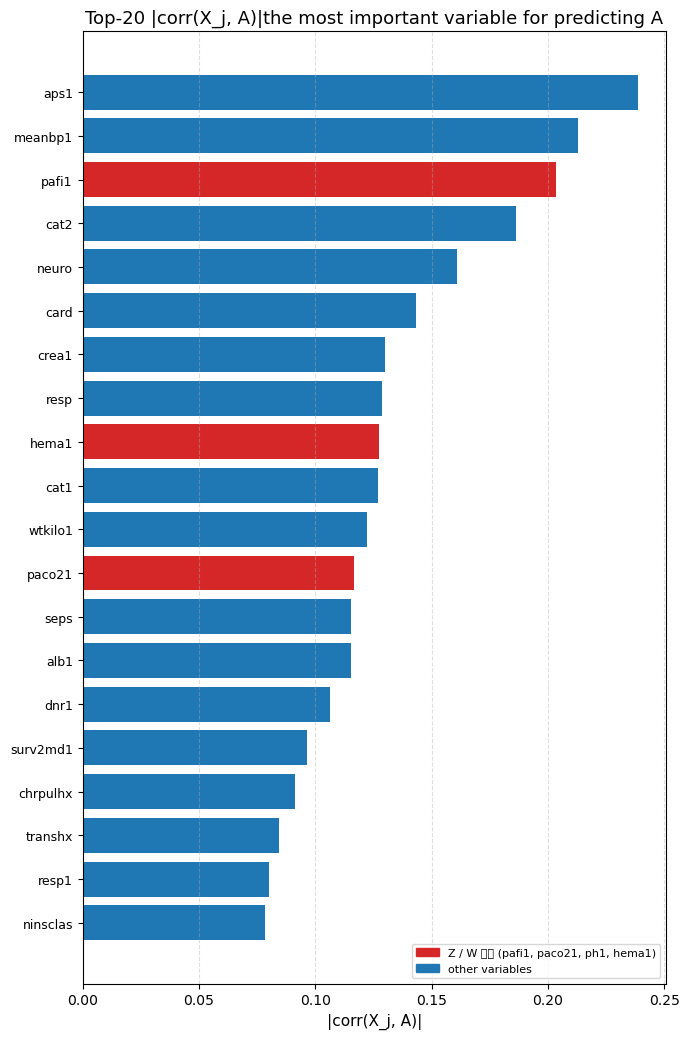

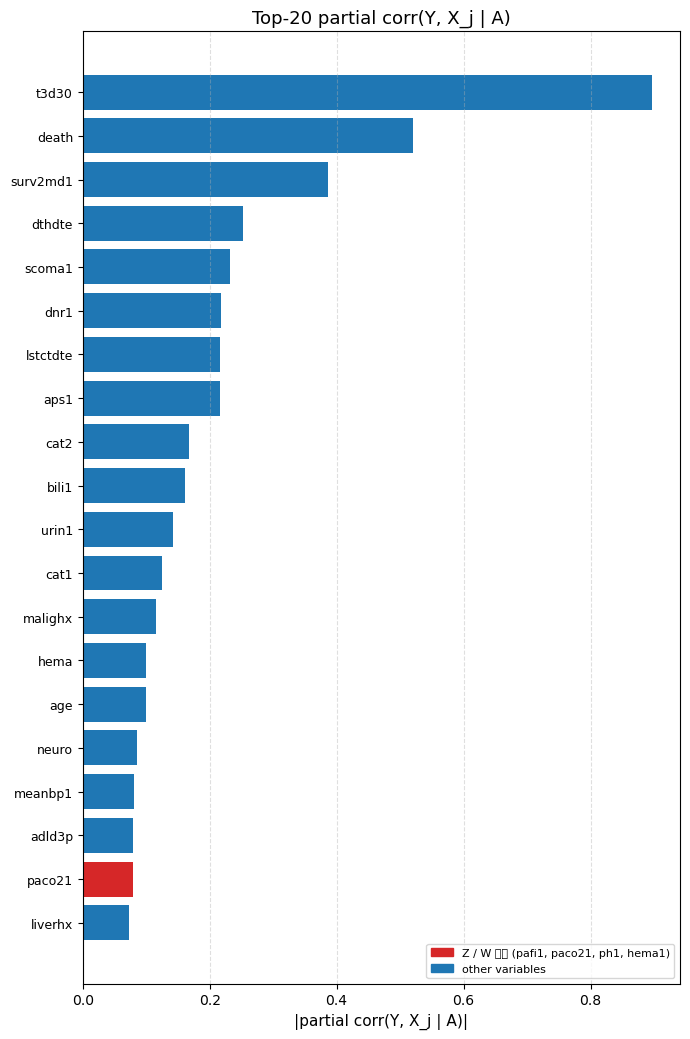

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== 1. 读入 & 基本预处理 ==========

# path = "rhc.csv"   # 改成你自己的路径
# df = pd.read_csv(path)

url = "https://hbiostat.org/data/repo/rhc.csv"  # 官方公开地址
df = pd.read_csv(url)



# Treatment A & outcome Y
A = (df["swang1"].astype(str).str.upper().str.strip() == "RHC").astype(float)
Y = (df["dth30"].astype(str).str.upper().str.strip() == "NO").astype(float)

# X = 其余协变量（去掉明显是 ID / 行号的列）
drop_cols = ["swang1", "dth30", "ptid", "Unnamed: 0"]
X_cols = [c for c in df.columns if c not in drop_cols]

df_X = df[X_cols].copy()

# 把非数值变量编码成 category code，方便统一算相关系数
X_num = pd.DataFrame(index=df.index)
for c in X_cols:
    s = df_X[c]
    if not np.issubdtype(s.dtype, np.number):
        # category code: 缺失编码为 NaN
        X_num[c] = s.astype("category").cat.codes.replace(-1, np.nan).astype(float)
    else:
        X_num[c] = s.astype(float)

# 一个小工具：安全相关系数
def safe_corr(x, y):
    mask = (~x.isna()) & (~y.isna())
    if mask.sum() < 10:
        return np.nan
    return np.corrcoef(x[mask], y[mask])[0, 1]


# ========== 2.1  X_j 对预测 A 的“重要性”：|corr(X_j, A)| ==========

corr_A = {c: abs(safe_corr(X_num[c], A)) for c in X_cols}
imp_A = pd.Series(corr_A).sort_values(ascending=False)

print("=== 2.1 预测 A 最重要的前 20 个原始变量 (按 |corr(X_j, A)| 排序) ===")
for name, val in imp_A.head(20).items():
    print(f"{name:<10s}  importance = {val:.4f}")


# ========== 2.2  X_j 在 (X_j, A) → Y 中的“重要性” ==========
# 用 partial corr(Y, X_j | A)：先把 X_j 和 Y 都对 A 做线性回归残差，再算相关

def partial_corr_with_Y_given_A(x):
    x = x.astype(float)
    mask = (~x.isna()) & (~A.isna()) & (~Y.isna())
    if mask.sum() < 30:
        return np.nan
    x = x[mask]; a = A[mask]; y = Y[mask]

    # 设计矩阵 [1, A]
    X_design = np.vstack([np.ones_like(a.values), a.values]).T

    # 残差 r_x
    beta_x, *_ = np.linalg.lstsq(X_design, x.values, rcond=None)
    r_x = x.values - X_design @ beta_x

    # 残差 r_y
    beta_y, *_ = np.linalg.lstsq(X_design, y.values, rcond=None)
    r_y = y.values - X_design @ beta_y

    if r_x.std() == 0 or r_y.std() == 0:
        return np.nan
    return np.corrcoef(r_x, r_y)[0, 1]


partial_scores = {c: abs(partial_corr_with_Y_given_A(X_num[c])) for c in X_cols}
imp_Y = pd.Series(partial_scores).sort_values(ascending=False)

print("\n=== 2.2 在 (X_j, A) → Y 中最重要的前 20 个原始变量 (按 partial corr 排序) ===")
for name, val in imp_Y.head(20).items():
    print(f"{name:<10s}  importance = {val:.4f}")


# ========== 3. 精美可视化：横向 bar plot，高亮 Z/W 四个变量 ==========

Z_cols = ["pafi1", "paco21"]
W_cols = ["ph1", "hema1"]
highlight = set(Z_cols + W_cols)

def plot_importance(imp_series, top_k, title, xlabel):
    top = imp_series.head(top_k)[::-1]  # 反转，方便从上到下显示
    colors = ["C3" if name in highlight else "C0" for name in top.index]

    plt.figure(figsize=(7, 0.45 * top_k + 1.5))
    plt.barh(range(len(top)), top.values, color=colors)
    plt.yticks(range(len(top)), top.index, fontsize=9)
    plt.xlabel(xlabel, fontsize=11)
    plt.title(title, fontsize=13)

    # 图例
    from matplotlib.patches import Patch
    handles = [
        Patch(color="C3", label="Z / W  (pafi1, paco21, ph1, hema1)"),
        Patch(color="C0", label="other variables"),
    ]
    plt.legend(handles=handles, loc="lower right", fontsize=8)
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()

# 图 1：预测 A 的前 20 个变量
plot_importance(
    imp_A,
    top_k=20,
    title="Top-20 |corr(X_j, A)|the most important variable for predicting A",
    xlabel="|corr(X_j, A)|",
)

# 图 2：在 (X_j, A) → Y 中的前 20 个变量
plot_importance(
    imp_Y,
    top_k=20,
    title="Top-20 partial corr(Y, X_j | A)",
    xlabel="|partial corr(Y, X_j | A)|",
)

plt.show()


=== 2.1 只用 10 个生理变量预测 A 的重要性排序 ===
pafi1    importance = 0.5244
paco21   importance = 0.4061
ph1      importance = 0.2391
crea1    importance = 0.2303
alb1     importance = 0.1490
pot1     importance = 0.1292
hema1    importance = 0.1064
sod1     importance = 0.1048
bili1    importance = 0.0940
wblc1    importance = 0.0059


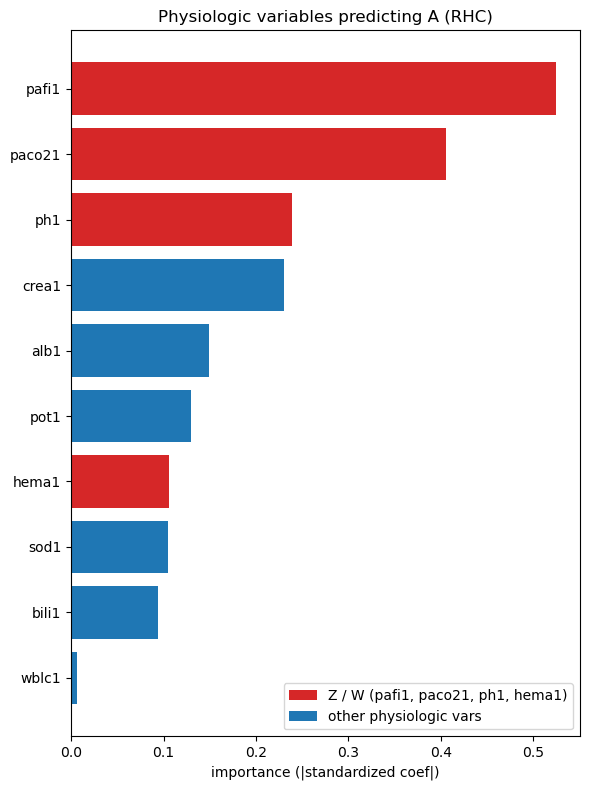


=== 2.2 在预测 Y | (A, X_phys) 时的 10 个生理变量重要性排序 ===
bili1    importance = 0.3305
paco21   importance = 0.2504
ph1      importance = 0.1625
pafi1    importance = 0.1122
alb1     importance = 0.0799
hema1    importance = 0.0478
sod1     importance = 0.0406
wblc1    importance = 0.0249
pot1     importance = 0.0107
crea1    importance = 0.0042


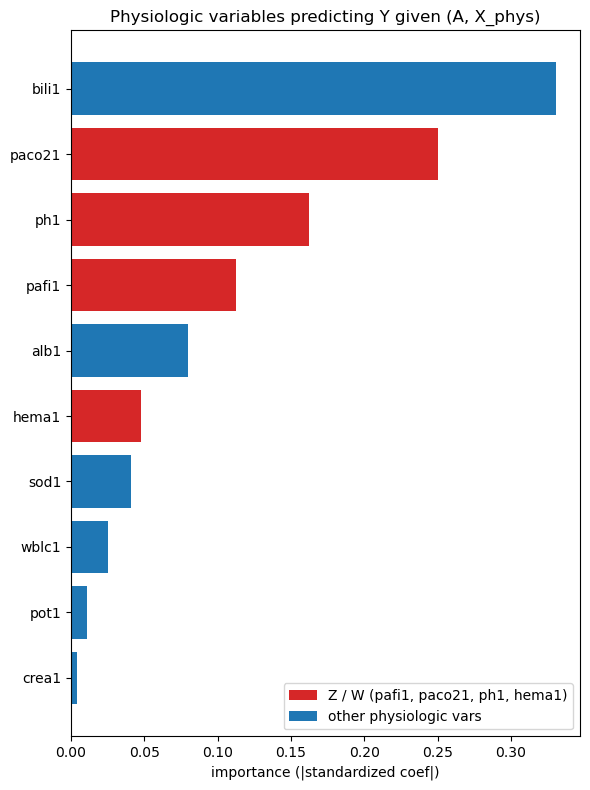


Top-4 (2.1, predict A): ['pafi1', 'paco21', 'ph1', 'crea1']
Top-4 (2.2, predict Y | A,X_phys): ['bili1', 'paco21', 'ph1', 'pafi1']
Paper's Z/W vars: ['pafi1', 'paco21', 'ph1', 'hema1']


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from matplotlib.patches import Patch


# ===================== 1. 读取 RHC 数据 =====================
# 如果你已经有本地文件，可以改成：pd.read_csv("rhc.csv")
url = "https://hbiostat.org/data/repo/rhc.csv"
df = pd.read_csv(url)

# Treatment A: swang1 是否 RHC
A_raw = df["swang1"].astype(str).str.upper().str.strip()
A = (A_raw == "RHC").astype(int).values  # 0/1

# Outcome Y: dth30 == "NO" 视为存活（和论文方向一致）
Y_raw = df["dth30"].astype(str).str.upper().str.strip()
Y = (Y_raw == "NO").astype(int).values  # 0/1

# 10 个生理变量（来自 RHC 数据字典）
phys_vars = [
    "sod1",   # sodium
    "pot1",   # potassium
    "crea1",  # creatinine
    "bili1",  # bilirubin
    "alb1",   # albumin
    "pafi1",  # PaO2/FiO2
    "paco21", # PaCO2
    "ph1",    # arterial pH
    "wblc1",  # white blood cell count
    "hema1",  # hematocrit
]

missing = [v for v in phys_vars if v not in df.columns]
if missing:
    raise ValueError(f"这些列在 rhc.csv 中没找到: {missing}")

# 把 10 个变量转为数值 + 缺失值用列均值填补
X_phys = pd.DataFrame(
    {col: pd.to_numeric(df[col], errors="coerce") for col in phys_vars}
)
X_phys = X_phys.replace([np.inf, -np.inf], np.nan)
X_phys = X_phys.fillna(X_phys.mean())


# 用来高亮的 4 个负控：Z_cols + W_cols
zw_set = {"pafi1", "paco21", "ph1", "hema1"}


# 一个小工具函数：画横向条形图并高亮 Z/W 变量
def plot_importance(series, title):
    """
    series: pd.Series, index=variable name, values=importance (已排序好，降序)
    """
    # 为了 barh 从上到下好看一点，这里翻转一下
    s = series.iloc[::-1]

    colors = ["tab:red" if v in zw_set else "tab:blue" for v in s.index]

    fig, ax = plt.subplots(figsize=(6, 8))
    ax.barh(s.index, s.values, color=colors)
    ax.set_xlabel("importance (|standardized coef|)")
    ax.set_title(title)

    # 图例
    legend_elems = [
        Patch(facecolor="tab:red", label="Z / W (pafi1, paco21, ph1, hema1)"),
        Patch(facecolor="tab:blue", label="other physiologic vars"),
    ]
    ax.legend(handles=legend_elems, loc="lower right")

    plt.tight_layout()
    plt.show()


# ===================== 2.1 只用 10 个生理变量预测 A =====================
# Logistic 回归 + 标准化，取标准化后系数的绝对值作为重要性
pipe_A = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, penalty="l2", solver="lbfgs")
)
pipe_A.fit(X_phys, A)

logreg_A = pipe_A.named_steps["logisticregression"]
coefs_A = np.abs(logreg_A.coef_[0])  # 10 维

importance_A = pd.Series(coefs_A, index=phys_vars).sort_values(ascending=False)

print("=== 2.1 只用 10 个生理变量预测 A 的重要性排序 ===")
for name, val in importance_A.items():
    print(f"{name:7s}  importance = {val:.4f}")

plot_importance(importance_A,
                "Physiologic variables predicting A (RHC)")


# ===================== 2.2 在预测 Y | (A, X_phys) 时的变量重要性 =====================
# 特征：A + 10 个生理变量（总共 11 维）
X_Y = X_phys.copy()
X_Y.insert(0, "A", A)  # 把 A 放在第一列

pipe_Y = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, penalty="l2", solver="lbfgs")
)
pipe_Y.fit(X_Y, Y)

logreg_Y = pipe_Y.named_steps["logisticregression"]
coefs_Y = np.abs(logreg_Y.coef_[0])  # 对应 ['A'] + phys_vars

# 把系数转成 Series，并只保留 phys_vars 部分
all_cols = X_Y.columns.tolist()
coef_series = pd.Series(coefs_Y, index=all_cols)
importance_Y = coef_series.loc[phys_vars].sort_values(ascending=False)

print("\n=== 2.2 在预测 Y | (A, X_phys) 时的 10 个生理变量重要性排序 ===")
for name, val in importance_Y.items():
    print(f"{name:7s}  importance = {val:.4f}")

plot_importance(importance_Y,
                "Physiologic variables predicting Y given (A, X_phys)")

# ===================== 3. 打印各自前 4 个变量方便和论文对比 =====================
top4_A = importance_A.index[:4].tolist()
top4_Y = importance_Y.index[:4].tolist()

print("\nTop-4 (2.1, predict A):", top4_A)
print("Top-4 (2.2, predict Y | A,X_phys):", top4_Y)
print("Paper's Z/W vars: ['pafi1', 'paco21', 'ph1', 'hema1']")
